Jo Bovy (Toronto) has written a book on galactic dynamics, https://galaxiesbook.org/, that
includes lots of integration with a python package (galpy) that he’s also written. Install
galpy and work through each of the code examples in section 7.3 of the book (“Gravitational
potentials from disk density distributions”), reproducing the figures and calculations. For
each of the examples, provide detailed documentation about what the code is doing, with
connections to the material in section 7.3 (or elsewhere).

## Section 7.3 "Gravitational potentials from disk density distributions" Examples
- 7.3.3.2. The razor-thin exponential disk
- 7.3.4.1. The double-exponential disk

My documentation is handwritten and attached.

c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\galpy\potential\RazorThinExponentialDiskPotential.py:103: RuntimeWarning: invalid value encountered in scalar multiply
  * (special.i0(y) * special.k0(y) - special.i1(y) * special.k1(y))

C:\Users\17135\AppData\Local\Temp\ipykernel_57772\1487760740.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return -self._cumulmassfunc(r)*R/r**3.



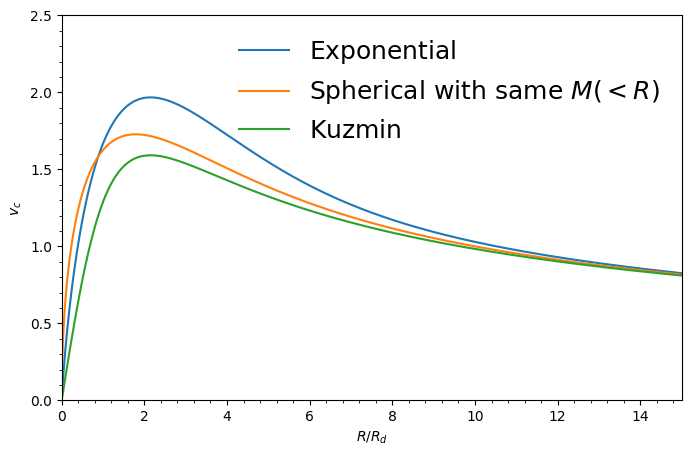

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import galpy as galpy
from galpy import potential

class EquivalentMassSphericalPotential(potential.Potential):
    def __init__(self,amp=1.,cumulmassfunc=None,ro=None,vo=None):
        potential.Potential.__init__(self,amp=amp,ro=ro,vo=vo)
        self._cumulmassfunc= cumulmassfunc
    def _Rforce(self,R,z,phi=0.,t=0.):
        r= np.sqrt(R**2.+z**2.)
        return -self._cumulmassfunc(r)*R/r**3.
plt.figure(figsize=(8,5))
Rd= 1.
kzp= potential.KuzminDiskPotential(amp=10.,a=2.15/np.sqrt(2.)*Rd)
rp= potential.RazorThinExponentialDiskPotential(amp=10./(2.*np.pi),hr=Rd)
rp_spher= EquivalentMassSphericalPotential(amp=10.,\
                cumulmassfunc=lambda R: Rd**2.-Rd*(R+Rd)*np.exp(-R/Rd))
line_rp= rp.plotRotcurve(Rrange=[0.,15.],\
                    label=r'$\mathrm{Exponential}$',yrange=[0.,2.5],
                    xlabel=r'$R/R_d$',ylabel=r'$v_c$',gcf=True)
line_rp_spher= rp_spher.plotRotcurve(Rrange=[0.,15.],\
                    label=r'$\mathrm{Spherical\ with\ same}\ M(<R)$',
                    overplot=True)
line_kuzmin= kzp.plotRotcurve(Rrange=[0.,15.],\
                    label=r'$\mathrm{Kuzmin}$',
                    overplot=True)
plt.legend(handles=[line_rp[0],line_rp_spher[0],line_kuzmin[0]],
       fontsize=18.,loc='upper right',frameon=False);



c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\galpy\potential\DoubleExponentialDiskPotential.py:19: RuntimeWarning: overflow encountered in sinh
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\galpy\potential\DoubleExponentialDiskPotential.py:20: RuntimeWarning: overflow encountered in cosh
  numpy.cosh(numpy.pi * numpy.sinh(t)) + 1

c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\galpy\potential\DoubleExponentialDiskPotential.py:19: RuntimeWarning: invalid value encountered in divide
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\galpy\potential\DoubleExponentialDiskPotential.py:224: RuntimeWarning: divide by zero encountered in scalar divide
  -4.0

c:\Users\17135\AppData\Local\Programs\Python\Python39\lib\site-packages\g

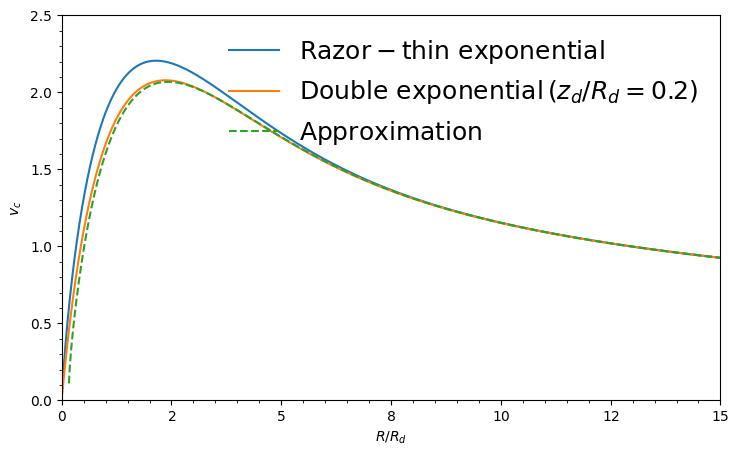

In [ ]:
from scipy import special
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8.5,5))
Rd= 0.2
zd= 0.2*0.2
rp= potential.RazorThinExponentialDiskPotential(amp=10.,hr=Rd)
dp= potential.DoubleExponentialDiskPotential(amp=10./2./zd,hr=Rd,hz=zd)
line_rp= rp.plotRotcurve(Rrange=[0.,3.],\
                    label=r'$\mathrm{Razor-thin\ exponential}$',
                    yrange=[0.,2.5],gcf=True,
                    xlabel=r'$R/R_d$',ylabel=r'$v_c$')
line_dp= dp.plotRotcurve(Rrange=[0.,3.],\
                    label=r'$\mathrm{Double\ exponential}\,(z_d/R_d = 0.2)$',
                    overplot=True)

# Also compute the approximation above
Rs= np.linspace(0.,3.,1001)
line_approx= plt.plot(Rs,np.sqrt(np.pi*rp._amp*Rs**2./Rd\
                  *(special.i0(Rs/2./Rd)*special.k0(Rs/2/Rd)
                      -special.i1(Rs/2/Rd)*special.k1(Rs/2./Rd))\
                    -2*np.pi*rp._amp*Rs*zd/Rd*np.exp(-Rs/Rd)),
                 label=r'$\mathrm{Approximation}$',ls='--')
# To get the ticklabels correct, need to multiply the labels
def perRd(x,pos):
    return r'$%.0f$' % (x*5.)
plt.gca().xaxis.set_major_formatter(FuncFormatter(perRd))
plt.legend(handles=[line_rp[0],line_dp[0],line_approx[0]],
       fontsize=12.,loc='upper right',frameon=False);



In [ ]:
from scipy import optimize, special
# defined from equation 7.49 in Bovy's book
def dvc2dr(R):
    Rd = 1.0 # Bovy set this to 1 in another example

    I0 = special.iv(0, R / (2.0 * Rd)) # the I and K in 7.49 were given to be Bessel functions
    I1 = special.iv(1, R / (2.0 * Rd)) # scipy has the Bessel functions (used in previous example)

    K0 = special.kv(0, R / (2.0 * Rd)) 
    K1 = special.kv(1, R / (2.0 * Rd))

    return 2.0 * (R / Rd) * I0 * K0 - (R**2 / Rd**2) * (I0 * K1 - I1 * K0) 
# eq 7.49 without prefactor

# the example gave this code but I had to set the accompanying function
opt= optimize.brentq(dvc2dr,2.,3.)
print("The exponential-disk rotation curve peaks at R/R_d = %.3f" % opt)

# this code numerically solves for where the above derivative = 0 in the range 2 < R/Rd < 3
# brentq from scipy.optimize just finds the root of a given function over some interval

The exponential-disk rotation curve peaks at R/R_d = 2.150


Then, use galpy to calculate the gravitational potential for the Milky Way (See the docu-
mentation). 

Start with “MWPotential2014” but also consider a total mass of the Milky Way
that is 2x larger.

For both masses, plot the individual potentials (bulge, disk, dark matter)
and the total potential (one plot for each mass).

Do the same for the circular velocity curve
Vcirc(r) in both cases. 

If we add a black hole of 4.3 × 106 M⊙ at the center, how far out in
radius will the affect the total circular velocity and total potential?

In [ ]:
from galpy.potential.mwpotentials import MWPotential2014
# I wanted to be thorough so I calculated this separately instead of using the import

[<galpy.potential.PowerSphericalPotentialwCutoff.PowerSphericalPotentialwCutoff object at 0x000001C2FE7B4100>, <galpy.potential.MiyamotoNagaiPotential.MiyamotoNagaiPotential object at 0x000001C2FE7B4070>, <galpy.potential.TwoPowerSphericalPotential.NFWPotential object at 0x000001C2FE7B4160>]


Text(0.5, 1.0, 'Dark Matter Halo Potential Component for 2x Dark Matter Halo Modified MWPotential2014')

<Figure size 700x600 with 0 Axes>

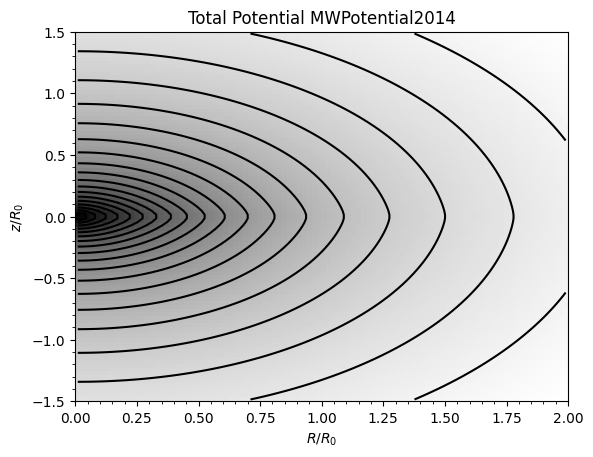

<Figure size 700x600 with 0 Axes>

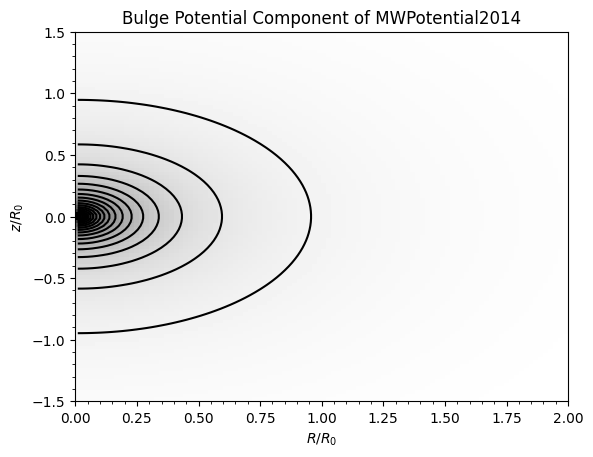

<Figure size 700x600 with 0 Axes>

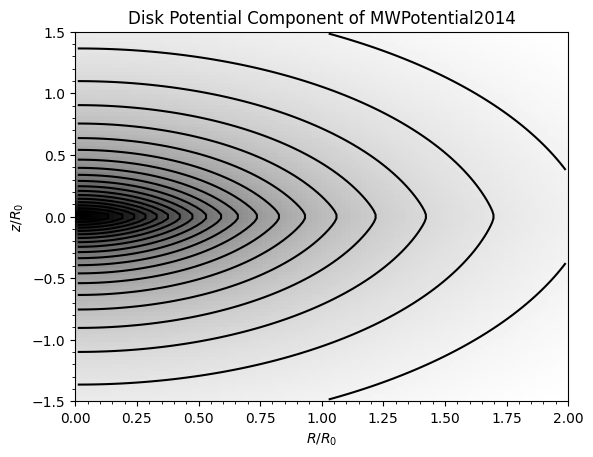

<Figure size 700x600 with 0 Axes>

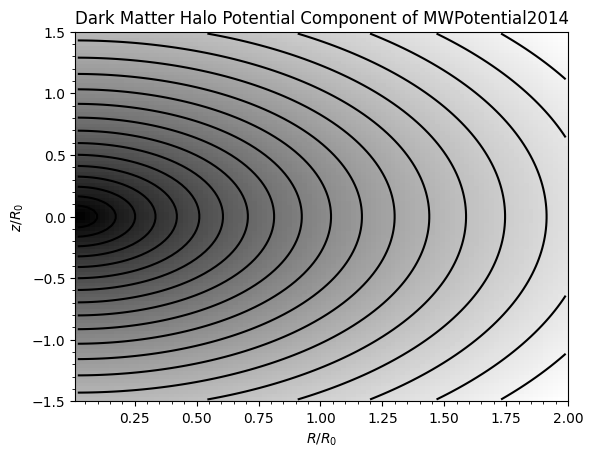

<Figure size 700x600 with 0 Axes>

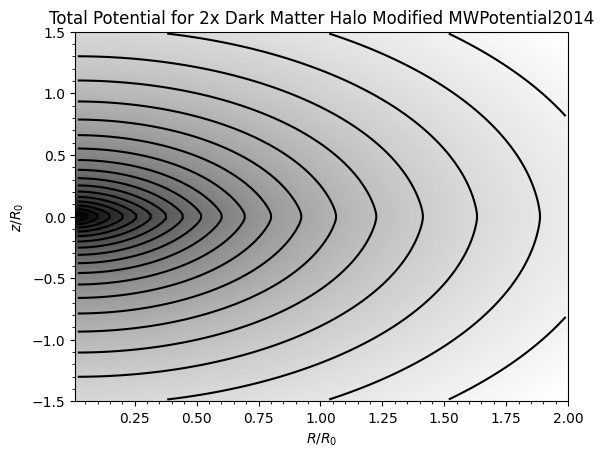

<Figure size 700x600 with 0 Axes>

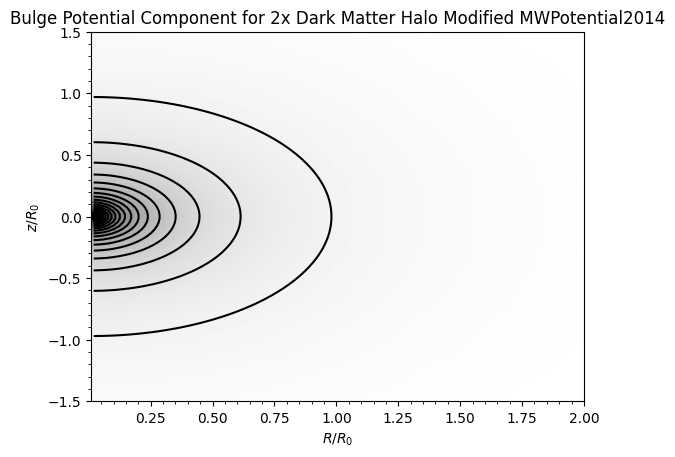

<Figure size 700x600 with 0 Axes>

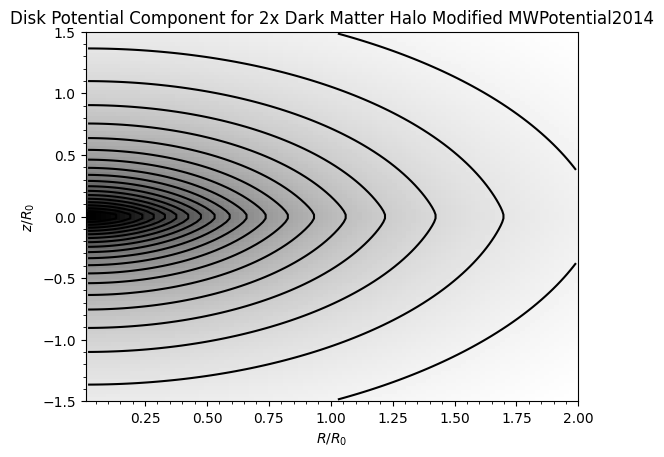

<Figure size 700x600 with 0 Axes>

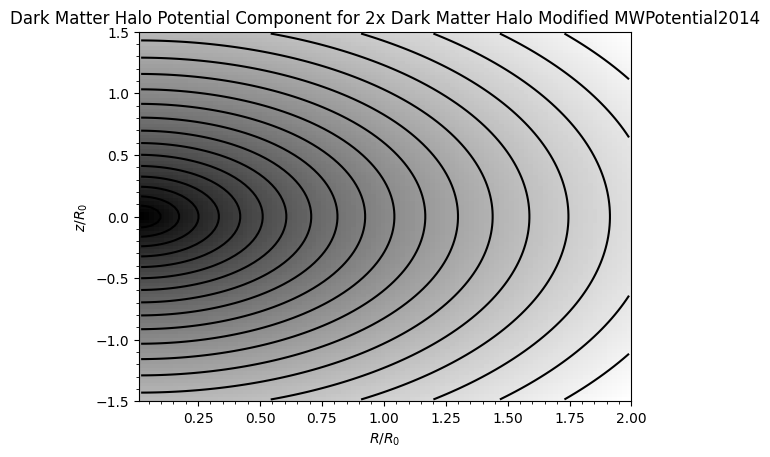

In [ ]:
# turned out to not be necessary but I did it so I left it here just in case

from galpy.potential import PowerSphericalPotentialwCutoff, MiyamotoNagaiPotential, NFWPotential
from galpy.potential import plotPotentials

bp= PowerSphericalPotentialwCutoff(alpha=1.8,rc=1.9/8.,normalize=0.05)
mp= MiyamotoNagaiPotential(a=3./8.,b=0.28/8.,normalize=.6)
nfwp= NFWPotential(a=16/8.,normalize=.35)
MWPotential2014= bp+mp+nfwp
# print(MWPotential2014) # this is the potential of the Milky Way

# Mass 1 plotting potential components 

# just played around to pick the best looking window
rmax = 2
zmax = 1.5

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential2014, rmin=0.0, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Total Potential MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential2014[0], rmin=0.0, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Bulge Potential Component of MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential2014[1], rmin=0.0, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Disk Potential Component of MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential2014[2], rmin=0.01, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Dark Matter Halo Potential Component of MWPotential2014")

# Mass 2

MWPotential2014[2]*= 2 # dark matter halo component only

MWPotential_2x = MWPotential2014[0] + MWPotential2014[1] + MWPotential2014[2]

#print(MWPotential_2x) # this is the potential for the total mass of the Milky Way

# Mass 2 plotting potential components
plt.figure(figsize=(7, 6))
plotPotentials(MWPotential_2x, rmin=0.01, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Total Potential for 2x Dark Matter Halo Modified MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential_2x[0], rmin=0.01, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Bulge Potential Component for 2x Dark Matter Halo Modified MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential_2x[1], rmin=0.01, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Disk Potential Component for 2x Dark Matter Halo Modified MWPotential2014")

plt.figure(figsize=(7, 6))
plotPotentials(MWPotential_2x[2], rmin=0.01, rmax=rmax, zmin=-zmax, zmax=zmax,
               nrs=100, nzs=100)
plt.title("Dark Matter Halo Potential Component for 2x Dark Matter Halo Modified MWPotential2014")


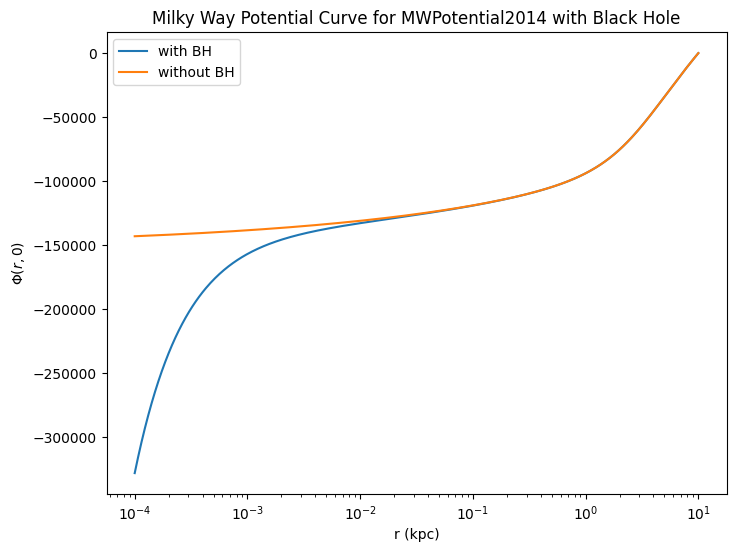

C:\Users\17135\AppData\Local\Temp\ipykernel_57772\3049830163.py:57: RuntimeWarning: invalid value encountered in divide
  fraction_potential = difference_potential / np.abs(potential_tot_1)

Potential curves start to agree within 1% at r = 0.014599186524739786 kpc


<Figure size 800x600 with 0 Axes>

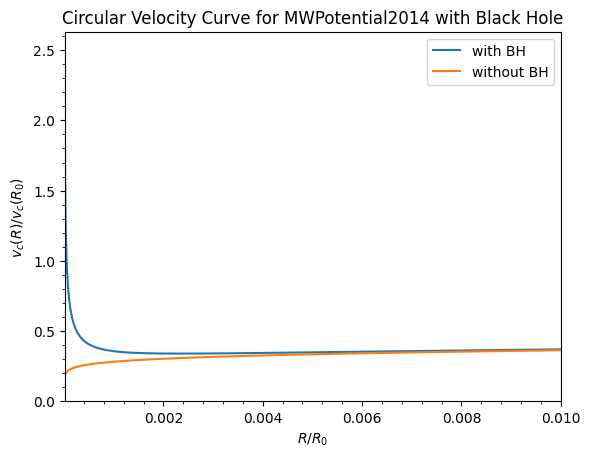

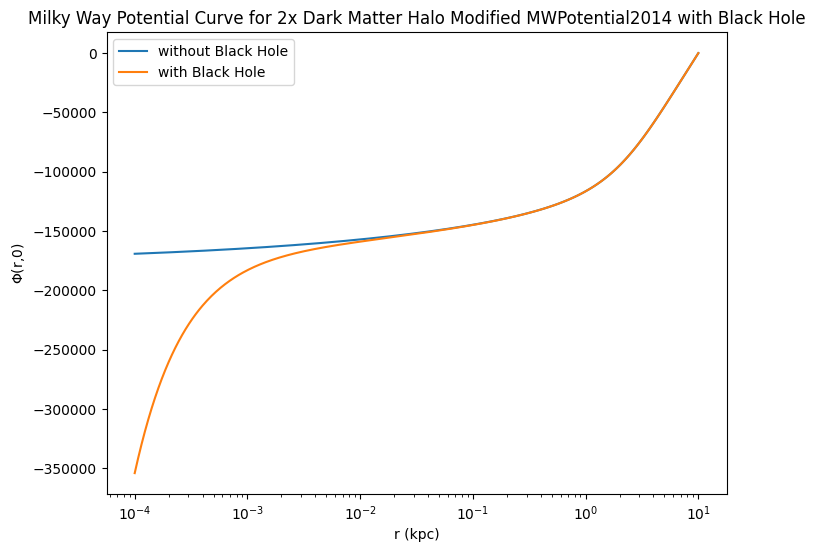

C:\Users\17135\AppData\Local\Temp\ipykernel_57772\3049830163.py:101: RuntimeWarning: invalid value encountered in divide
  fraction_potential_2 = difference_potential_2 / np.abs(potential_tot_2)

Potential curves start to agree within 1% at r = 0.01186173716452478 kpc


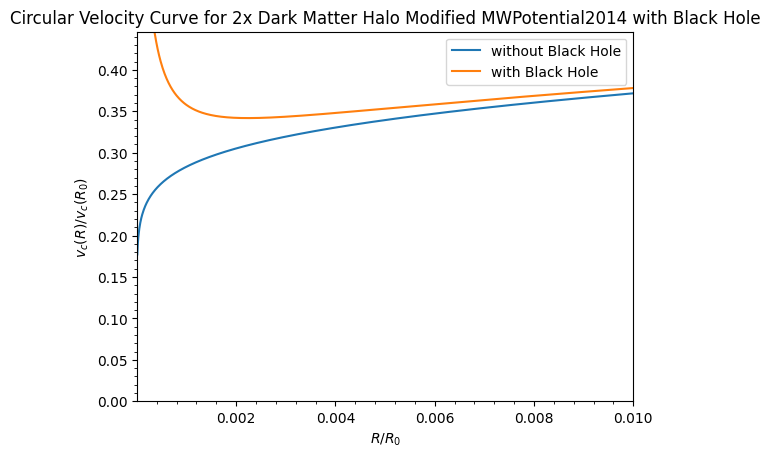

In [76]:
# adding black hole to the center of Milky Way
from galpy.potential import PowerSphericalPotentialwCutoff, MiyamotoNagaiPotential, NFWPotential
from galpy.potential import plotRotcurve, evaluatePotentials
from galpy.potential import KeplerPotential
from galpy.util import conversion
import numpy as np

bp= PowerSphericalPotentialwCutoff(alpha=1.8,rc=1.9/8.,normalize=0.05)
mp= MiyamotoNagaiPotential(a=3./8.,b=0.28/8.,normalize=.6)
nfwp= NFWPotential(a=16/8.,normalize=.35)
MWPotential2014= bp+mp+nfwp

MWPotential2014wBH = MWPotential2014+KeplerPotential(amp=4.3*10**6./conversion.mass_in_msol(220.,8.))

r = np.logspace(-4, 1, 500)
R = r / 8.0 # same as below to do calculations in galpy units and make x axis in kpc

potential_tot_1_BH = []
potential_tot_1 = []

for r_i in R:
    potential_tot_1_BH.append(evaluatePotentials(MWPotential2014wBH, r_i, 0.0))
    potential_tot_1.append(evaluatePotentials(MWPotential2014, r_i, 0.0))

potential_tot_1   = np.array(potential_tot_1)   - potential_tot_1[-1]
potential_tot_1_BH   = np.array(potential_tot_1_BH)   - potential_tot_1_BH[-1]

potential_tot_1   = potential_tot_1 * 220.0**2
potential_tot_1_BH   = potential_tot_1_BH * 220.0**2

plt.figure(figsize=(8,6))
plt.semilogx(r, potential_tot_1_BH, label='with BH')
plt.semilogx(r, potential_tot_1, label='without BH')
plt.xlabel('r (kpc)')
plt.ylabel(r'$\Phi(r,0)$')
plt.title('Milky Way Potential Curve for MWPotential2014 with Black Hole')
plt.legend()
plt.show()

# Circular Velocity Curve

plt.figure(figsize=(8,6))
plotRotcurve(MWPotential2014wBH, Rrange=[1e-5, 0.01], label='with BH')
plotRotcurve(MWPotential2014, Rrange=[1e-5, 0.01], overplot=True, label = 'without BH')
plt.title("Circular Velocity Curve for MWPotential2014 with Black Hole")
plt.legend()

# need to find actual radius where potential curves start agreeing
# idk if they will intersect or just get closer to each other
# so making the criteria that they need to be within a percent of each other
# ie. change in potential over OG potential = 1% = .01 

potential_tot_1_BH = np.array(potential_tot_1_BH) # need to convert from list to array
potential_tot_1 = np.array(potential_tot_1) # otherwise type error :(

difference_potential = np.abs(potential_tot_1_BH - potential_tot_1)
fraction_potential = difference_potential / np.abs(potential_tot_1)

potential_percent = np.where(fraction_potential < 0.01)[0]
if len(potential_percent) > 0:
    print("Potential curves start to agree within 1% at r =", r[potential_percent[0]], "kpc")


# now for mass 2

MWPotential_2x_wBH = MWPotential_2x + KeplerPotential(amp=4.3*10**6./conversion.mass_in_msol(220.,8.))

potential_tot_2 = []
potential_tot_2_BH = []

for r_i in R:
    potential_tot_2.append(evaluatePotentials(MWPotential_2x, r_i, 0.0))
    potential_tot_2_BH.append(evaluatePotentials(MWPotential_2x_wBH, r_i, 0.0))

potential_tot_2   = np.array(potential_tot_2)   - potential_tot_2[-1]
potential_tot_2_BH   = np.array(potential_tot_2_BH)   - potential_tot_2_BH[-1]

potential_tot_2   = potential_tot_2 * 220.0**2
potential_tot_2_BH   = potential_tot_2_BH * 220.0**2

plt.figure(figsize=(8,6))
plt.semilogx(r, potential_tot_2, label='without Black Hole')
plt.semilogx(r, potential_tot_2_BH, label='with Black Hole')
plt.xlabel('r (kpc)')
plt.ylabel(r'$\Phi$(r,0)')
plt.title('Milky Way Potential Curve for 2x Dark Matter Halo Modified MWPotential2014 with Black Hole')
plt.legend()
plt.show()

# Mass 2 Circular Velocity Curve

plotRotcurve(MWPotential_2x, Rrange=[1e-5, 0.01], label='without Black Hole')
plotRotcurve(MWPotential_2x_wBH, Rrange=[1e-5, 0.01],  overplot=True, label='with Black Hole')
plt.title("Circular Velocity Curve for 2x Dark Matter Halo Modified MWPotential2014 with Black Hole")
plt.legend()

potential_tot_2_BH = np.array(potential_tot_2_BH) # need to convert from list to array
potential_tot_2 = np.array(potential_tot_2) # otherwise type error :(

difference_potential_2 = np.abs(potential_tot_2_BH - potential_tot_2)
fraction_potential_2 = difference_potential_2 / np.abs(potential_tot_2)

potential_percent_2 = np.where(fraction_potential_2 < 0.01)[0]
if len(potential_percent_2) > 0:
    print("Potential curves start to agree within 1% at r =", r[potential_percent_2[0]], "kpc")


If we add a black hole to the center of the Milky Way, the impact on the circular velocity curve and total potential is limited to the inner part of the galaxy at small radii away from the center. As we get further away from the center of the galaxy, these quantities are not altered in any significant manner. The black hole will appreciably effect the total potential and circular velocity up to the radius from the center of the galaxy being on the order of tens of parsecs, after which the contribution becomes moot. I had to use a log scale to be able to zoom into the right window because before I was too zoomed out to see any difference with and without the black hole. Based on finding the difference within a percent between the two potential curves, it is clear that around 14 parsecs (unmodified potential) or 11 parsecs (modified potential) is where the difference between the potentials, and thus, the impact of the central black hole, starts being much less significant. I opted to not do a similar trick with the circular velocity data since plotRotcurve doesn't let you pull out the raw vcirc calculation, but also it does seem visually evident that the order of tens of parsecs is reasonable. 

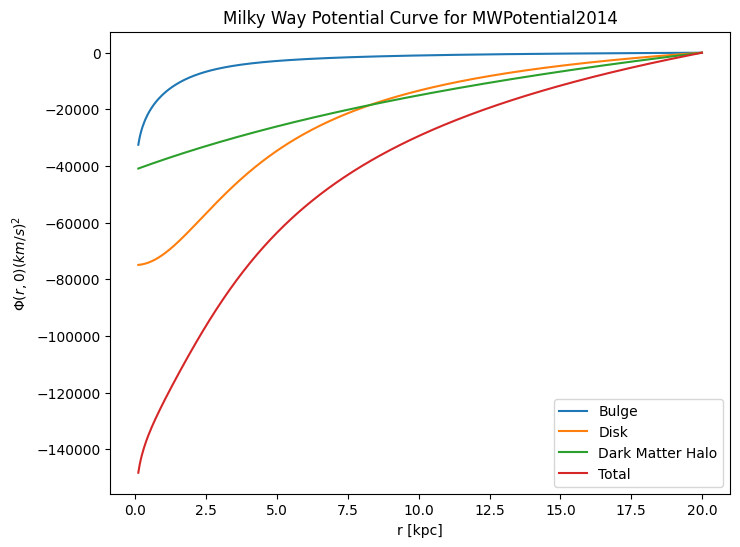

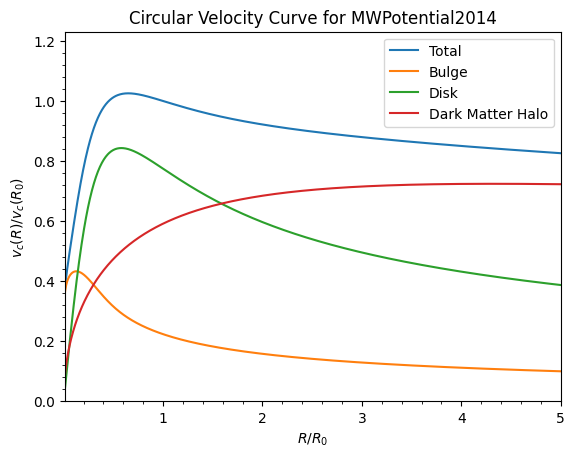

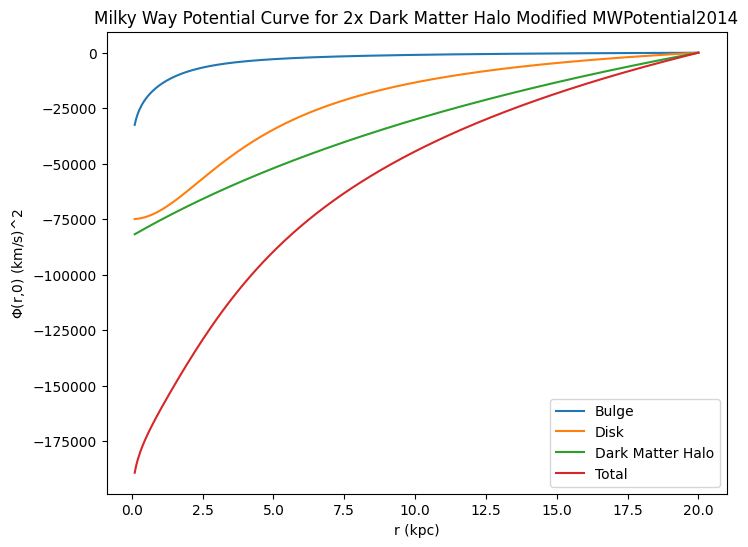

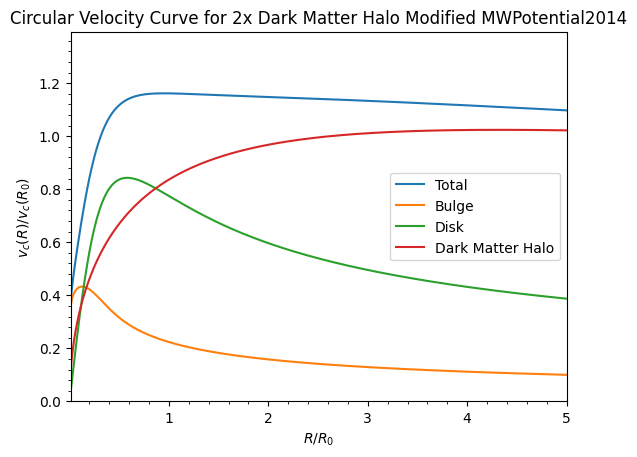

In [75]:
from galpy.potential import PowerSphericalPotentialwCutoff, MiyamotoNagaiPotential, NFWPotential
from galpy.potential import plotRotcurve, evaluatePotentials
import numpy as np

bp= PowerSphericalPotentialwCutoff(alpha=1.8,rc=1.9/8.,normalize=0.05)
mp= MiyamotoNagaiPotential(a=3./8.,b=0.28/8.,normalize=.6)
nfwp= NFWPotential(a=16/8.,normalize=.35)
MWPotential2014= bp+mp+nfwp
# print(MWPotential2014) # this is the potential of the Milky Way

# Mass 1 plotting potentials after evaluating
r = np.linspace(0.1, 20.0, 500)
R = r / 8.0 # scale by milky way radius to 
# evaluate potentials in galpy's units 
# (assumed that's what "can be Quantity" meant from docs?) 

potential_bulge_1 = []
potential_disk_1 = []
potential_dm_1 = []
potential_tot_1 = []

for r_i in R:
    potential_bulge_1.append(evaluatePotentials(MWPotential2014[0], r_i, 0.0))
    potential_disk_1.append(evaluatePotentials(MWPotential2014[1], r_i, 0.0))
    potential_dm_1.append(evaluatePotentials(MWPotential2014[2], r_i, 0.0))
    potential_tot_1.append(evaluatePotentials(MWPotential2014, r_i, 0.0))

# need to convert to array from list to do this, just rescaling
# shifting the entire array by subracting each value by its last value
# thus the last value becomes zero and each potential type
# is shifted consistently relative to itself 
potential_bulge_1 = np.array(potential_bulge_1) - potential_bulge_1[-1]
potential_disk_1  = np.array(potential_disk_1)  - potential_disk_1[-1]
potential_dm_1    = np.array(potential_dm_1)    - potential_dm_1[-1]
potential_tot_1   = np.array(potential_tot_1)   - potential_tot_1[-1]

# ok I could be wrong but I think since the MW circular velocity is 220 km/s 
# I just need to scale by that squared to put the potential in physical units
# since the potential is proportional to vcirc^2
# I'm getting this from this line in the documentation under "Potentials in galpy":
# "The units of this parameter vary from potential to potential.
# For example, for a logarithmic potential the units are velocity squared,"
potential_bulge_1 = potential_bulge_1 * 220.0**2
potential_disk_1  = potential_disk_1 * 220.0**2
potential_dm_1    = potential_dm_1 * 220.0**2
potential_tot_1   = potential_tot_1 * 220.0**2

# plotting arrays vs lists doesn't matter I don't think
plt.figure(figsize=(8,6))
plt.plot(r, potential_bulge_1, label='Bulge')
plt.plot(r, potential_disk_1, label='Disk')
plt.plot(r, potential_dm_1, label='Dark Matter Halo')
plt.plot(r, potential_tot_1, label='Total')
plt.xlabel('r [kpc]')
plt.ylabel(r'$\Phi(r, 0) (km/s)^2$')
plt.title('Milky Way Potential Curve for MWPotential2014')
plt.legend()
plt.show()

# Mass 1 Plotting Circular Velocity Curve

plotRotcurve(MWPotential2014, label='Total')
plotRotcurve(MWPotential2014[0], label='Bulge', overplot=True)
plotRotcurve(MWPotential2014[1], label='Disk',  overplot=True)
plotRotcurve(MWPotential2014[2], label='Dark Matter Halo',  overplot=True)
plt.title("Circular Velocity Curve for MWPotential2014")
plt.legend()


# Mass 2

MWPotential2014[2]*= 2 # dark matter halo component

MWPotential_2x = MWPotential2014[0] + MWPotential2014[1] + MWPotential2014[2]

#print(MWPotential_2x) # this is the potential for the total mass of the Milky Way

# Mass 2 plotting potentials after evaluating
# same linspace as before
potential_bulge_2 = []
potential_disk_2 = []
potential_dm_2 = []
potential_tot_2 = []

for r_i in R:
    potential_bulge_2.append(evaluatePotentials(MWPotential_2x[0], r_i, 0.0))
    potential_disk_2.append(evaluatePotentials(MWPotential_2x[1], r_i, 0.0))
    potential_dm_2.append(evaluatePotentials(MWPotential_2x[2], r_i, 0.0))
    potential_tot_2.append(evaluatePotentials(MWPotential_2x, r_i, 0.0))

potential_bulge_2 = np.array(potential_bulge_2) - potential_bulge_2[-1]
potential_disk_2  = np.array(potential_disk_2)  - potential_disk_2[-1]
potential_dm_2    = np.array(potential_dm_2)    - potential_dm_2[-1]
potential_tot_2   = np.array(potential_tot_2)   - potential_tot_2[-1]

potential_bulge_2 = potential_bulge_2 * 220.0**2
potential_disk_2  = potential_disk_2 * 220.0**2
potential_dm_2    = potential_dm_2 * 220.0**2
potential_tot_2   = potential_tot_2 * 220.0**2

plt.figure(figsize=(8,6))
plt.plot(r, potential_bulge_2, label='Bulge')
plt.plot(r, potential_disk_2, label='Disk')
plt.plot(r, potential_dm_2, label='Dark Matter Halo')
plt.plot(r, potential_tot_2, label='Total')
plt.xlabel('r (kpc)')
plt.ylabel(r'$\Phi$(r,0) (km/s)^2')
plt.title('Milky Way Potential Curve for 2x Dark Matter Halo Modified MWPotential2014')
plt.legend()
plt.show()

# Mass 2 Circular Velocity Curve

plotRotcurve(MWPotential_2x, label='Total')
plotRotcurve(MWPotential_2x[0], label='Bulge', overplot=True)
plotRotcurve(MWPotential_2x[1], label='Disk',  overplot=True)
plotRotcurve(MWPotential_2x[2], label='Dark Matter Halo',  overplot=True)
plt.title("Circular Velocity Curve for 2x Dark Matter Halo Modified MWPotential2014")
plt.legend()